# Fixing the Spectral Index

In this tutorial, we will show how to initialise an analysis instance with a fixed spectral index. 

First, we initialize the logging, config, datasets, and source objects. Details on these can be found in the [Fitting a steady point-source with the public 14-year IceCube track data](fitting_a_source.ipynb) and [Dataset collections](dataset_collections.ipynb) tutorials.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import skyllh
from skyllh.core.config import Config
from skyllh.core.logging import setup_logging
from skyllh.core.random import RandomStateService
from skyllh.core.source_model import PointLikeSource

In [2]:
cfg = Config()
logger = setup_logging(cfg=cfg, name='fixed_spectral_index')
datasets = skyllh.create_datasets('IceTracks-DR1', cfg=cfg)

# Location of NGC 1068
src_ra = 40.67  # degrees
src_dec = -0.01  # degrees

source = PointLikeSource(ra=np.radians(src_ra), dec=np.radians(src_dec))

2026-05-19 14:37:57,104 MainProcess skyllh.datasets.datasets INFO: Loaded 5 dataset(s) from sample "IceTracks-DR1": IC40, IC59, IC79, IC86_I, IC86_II-VII


Then we initialize the analysis object as already shown in the [Fitting a steady point-source with the public 14-year IceCube track data](fitting_a_source.ipynb) tutorial, but we fix the seed, minimum and maximum values defining the spectral index parameter. This effectively fixes the spectral index to the desired value.

Let's say we want to fix the spectral index to 2.0. Then we need to pass `gamma_seed`, `gamma_min`, and `gamma_max` equal to 2.0 to the `create_analysis` method.

Additionally, one would also set the `refplflux_gamma` parameter to the same value of 2.0, as that parameter sets the power-law spectral index that is used for generating pseudo signal events.

In [3]:
from skyllh.analyses.i3.publicdata_ps.time_integrated_ps import create_analysis

ana = create_analysis(
    cfg=cfg,
    datasets=datasets,
    source=source,
    refplflux_gamma=2.0,
    gamma_seed=2.0,
    gamma_min=2.0,
    gamma_max=2.0,
)

2026-05-19 14:37:58,954 MainProcess skyllh.analyses.i3.publicdata_ps.time_integrated_ps INFO: SourceHypoGroupManager
    Source Hypothesis Groups:
        0: SourceHypoGroup:
            sources (1):
                0: PointLikeSource: "4570617168": { ra=40.670 deg, dec=-0.010 deg }
            fluxmodel:
                1.000e+00 * (E / (1000 GeV))^-2 * 1 (GeV cm^2 s)^-1
            detector signal yield builders (1):
                PDSingleParamFluxPointLikeSourceI3DetSigYieldBuilder
            signal generation method:
                NoneType
2026-05-19 14:37:58,954 MainProcess skyllh.analyses.i3.publicdata_ps.time_integrated_ps INFO: ParameterModelMapper: 2 global parameters, 2 models (1 source)
    Parameters:        
        ns [floating (0 <= 10 <= 1000)]
            in models:
            - IceCube: ns
                    
        gamma [floating (2 <= 2 <= 2)]
            in models:
            - 4570617168: gamma
            
  0%|          | 0/5 [00:00<?, ?it/s]2026-05-19

As a test, we can try to fit the location of NGC 1068 with the power-law spectral index in the likelihood fixed to 2.0, which is rather far from the best-fit value we obtain when the parameter is left floating (gamma = 3.2).

The resulting TS value is much lower when the fluxmodel does not match sources spectrum (free gamma index best-fit was: TS=29.154; ns=80.09; gamma=3.21), indicating reduced statistical power.

In [4]:
rss = RandomStateService(seed=1)

ts, fitparam_values, status = ana.unblind(rss)

print(f'TS = {ts:.3f}')
print(f'ns = {fitparam_values["ns"]:.2f}')
print(f'gamma = {fitparam_values["gamma"]:.2f}')

TS = 2.594
ns = 7.81
gamma = 2.00


## Background trials

We can also check how the best fit values look of the background pseudo trials:

In [5]:
rss = RandomStateService(seed=1)

trials = ana.do_trials(
    rss=rss,
    n=1000,
)

100%|██████████| 1000/1000 [00:52<00:00, 19.11it/s]


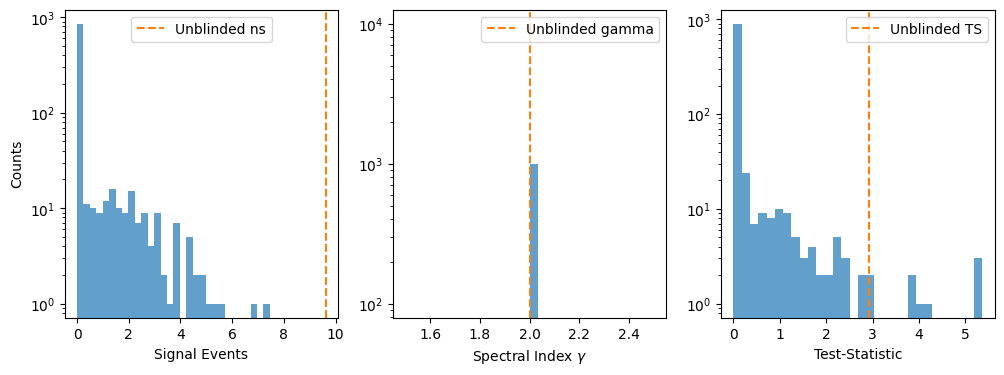

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].hist(trials['ns'], bins=30, color='C0', alpha=0.7)
ax[0].axvline(fitparam_values['ns'], color='C1', linestyle='--', label='Unblinded ns')
ax[0].legend()
ax[0].set_yscale('log')
ax[0].set_ylabel(r'Counts')
ax[0].set_xlabel(r'Signal Events')

ax[1].hist(trials['gamma'], bins=30, color='C0', alpha=0.7)
ax[1].axvline(fitparam_values['gamma'], color='C1', linestyle='--', label='Unblinded gamma')
ax[1].legend()
ax[1].set_yscale('log')
ax[1].set_xlabel(r'Spectral Index $\gamma$')

ax[2].hist(trials['ts'], bins=30, color='C0', alpha=0.7)
ax[2].axvline(ts, color='C1', linestyle='--', label='Unblinded TS')
ax[2].legend()
ax[2].set_yscale('log')
ax[2].set_xlabel('Test-Statistic')
plt.show()